# Discovery de telemetria

Este cuaderno sirve para entender que telemetria existe realmente antes de disenar un dashboard.

Consultas incluidas:
- 00_discovery_tables.kql
- 01_discovery_events.kql

Como jugar con los datos:
- Cambia DISCOVERY_DAYS para comparar semanas normales frente a picos.
- Usa las tablas y eventos con mas volumen como candidatos iniciales de dashboard.

In [1]:
import sys
from pathlib import Path

NOTEBOOK_CWD = Path.cwd()
candidate_roots = [
    NOTEBOOK_CWD,
    NOTEBOOK_CWD.parent if NOTEBOOK_CWD.name == 'notebooks' else NOTEBOOK_CWD,
    NOTEBOOK_CWD / 'observability' / 'd365-fo-observability',
]
PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / 'src' / 'kql_runner.py').exists() and (candidate / 'queries').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise RuntimeError('No se pudo localizar observability/d365-fo-observability desde el directorio actual')
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from kql_runner import build_client, get_auth_mode, load_config, load_kql, plot_bar, run_kql, validate_target_access

config = load_config()
client = build_client(config=config)
DISCOVERY_DAYS = config['query_days']
TOP_N = 20

print(f'Dias de analisis: {DISCOVERY_DAYS}')
print(f'Modo de autenticacion: {get_auth_mode(config=config)}')
validate_target_access(client, config=config)

Dias de analisis: 7
Modo de autenticacion: Service Principal (tenant explicito)
Target accesible (resource_id) y autenticacion OK


True

Ejecutando: Discovery tables
Filas devueltas: 3


,$table,Count
0,customEvents,135356
1,pageViews,3811
2,exceptions,178


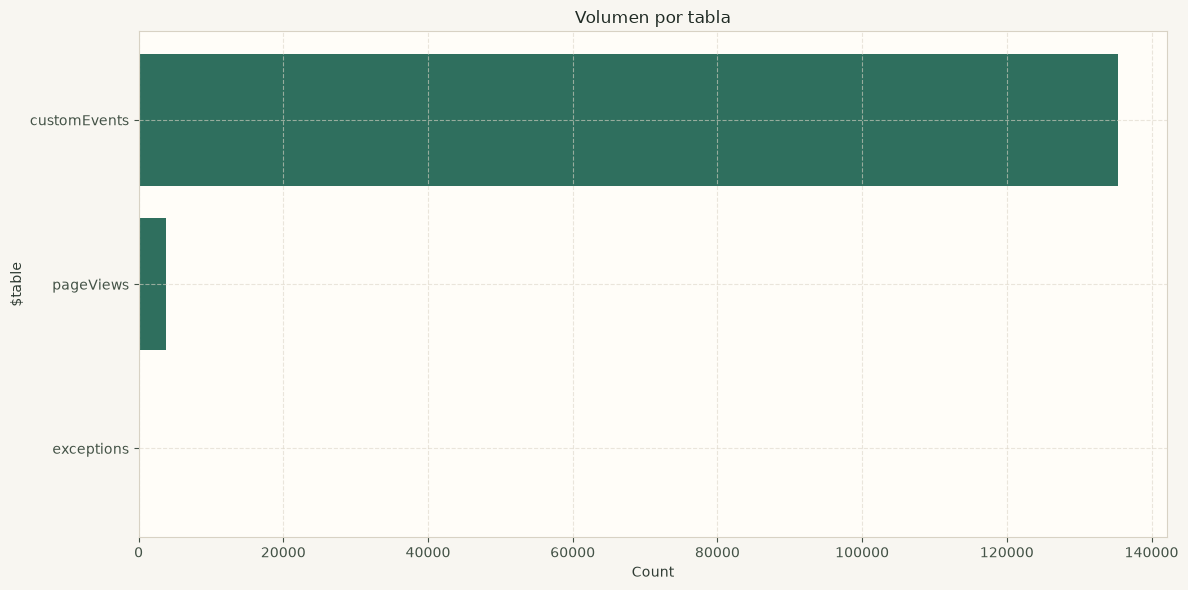

In [2]:
df_tables = run_kql(client, load_kql('00_discovery_tables.kql'), days=DISCOVERY_DAYS, name='Discovery tables', config=config)
display(df_tables.head(TOP_N))
plot_bar(df_tables, '$table', 'Count', 'Volumen por tabla', top_n=TOP_N)

Ejecutando: Discovery events
Filas devueltas: 5


,name,Count
0,BatchTaskStart,58081
1,BatchTaskFinished,58063
2,BatchThreadInfo,12602
3,BatchQueuesDetails,6609
4,BatchTaskFailure,1


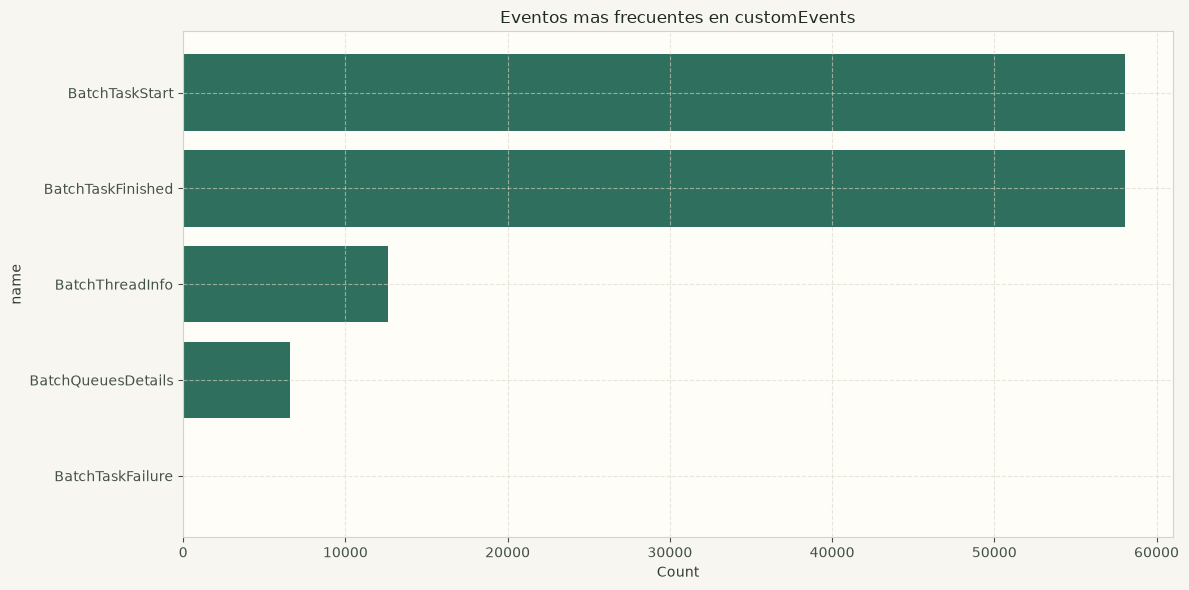

In [3]:
df_events = run_kql(client, load_kql('01_discovery_events.kql'), days=DISCOVERY_DAYS, name='Discovery events', config=config)
display(df_events.head(TOP_N))
plot_bar(df_events, 'name', 'Count', 'Eventos mas frecuentes en customEvents', top_n=TOP_N)

## Como interpretar los resultados

- Si una tabla domina el volumen total, merece una familia propia de consultas y visualizaciones.
- Si aparecen muchos nombres de eventos con poca recurrencia, probablemente convenga agrupar antes de llevarlos a dashboard.
- Discovery suele ser un paso previo: no siempre genera widgets finales, pero evita construir dashboards sobre datos inexistentes.